In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt


from numerical_approximation.chemotaxis import (
    ArcParams,
    ArcPhiParams,
    Endpoint,
    ExternalBC,
    InternalNode,
    arc_mass,
    plot_density_snapshots,
    step_network,
    validate_network,
)

Set up the parameters for the problem

In [2]:
# Arcs are 0-based: arc i here is arc i+1 in the sketch (p. 103 in the paper).
#   arc 0: N0 (inlet) -> N1
#   arc 1: N1 -> N2
#   arc 2: N2 -> N3
#   arc 3: N3 -> N4
#   arc 4: N4 -> N1
#   arc 5: N2 -> N4
#   arc 6: N3 -> N5 (outlet)
n_edges = 7

# Space step shared by every arc; 0.01 divides all the lengths (M_i = 19, 29, 199).
# Smaller steps grow memory quickly, since every time row is stored.
h_grid = 0.01

D = [1 for _ in range(n_edges)]
a = [1 for _ in range(n_edges)]
b = [0.1 for _ in range(n_edges)]
lam = math.sqrt(0.33)
_xi = 1/3 # All the xis are the same
_kappa = 1.0 # All the kappas are the same
chi = 1

# L_2 + L_6 < L_5 & L_4 + L_6 < L_3 (1-based, as in the sketch)
L = [0.2, 0.3, 2, 0.3, 2, 0.3, 0.2]
# The scheme assumes the CFL condition with equality, h_i = 2*k*lam, on every
# arc. With one lam that means one h for all arcs, so every L_i must be a
# whole multiple of h_grid, and each arc gets its own M_i = L_i/h_grid - 1.
M = [round(L[i] / h_grid) - 1 for i in range(n_edges)]
assert all(math.isclose((M[i] + 1) * h_grid, L[i]) for i in range(n_edges)), "every L_i must be a multiple of h_grid"
h = [h_grid for _ in range(n_edges)]
k = h_grid / (2 * lam)

arc_params = {i: ArcParams(lam=lam, h=h[i], k=k, chi=chi) for i in range(n_edges)}
phi_arc_params = {i: ArcPhiParams(D=D[i], a=a[i], b=b[i], h=h[i], k=k, M=M[i]) for i in range(n_edges)}

distribution_range = (0.45, 0.55)
rng = np.random.default_rng()


Set up the boundary conditions

In [3]:
# Endpoints meeting at each internal node.
# "left" is j=0, "right" is j=M+1
node_endpoints = {
    "N1": [Endpoint(0, "right"), Endpoint(4, "right"), Endpoint(1, "left")],
    "N2": [Endpoint(1, "right"), Endpoint(2, "left"), Endpoint(5, "left")],
    "N3": [Endpoint(2, "right"), Endpoint(6, "left"), Endpoint(3, "left")],
    "N4": [Endpoint(3, "right"), Endpoint(5, "right"), Endpoint(4, "left")],
}

# kappa (phi coupling) and xi (u/v coupling) are scoped to each node and
# keyed by the arcs meeting there; xi also needs the (i, i) self-pairs.
internal_nodes = []
for endpoints in node_endpoints.values():
    arcs = [ep.arc for ep in endpoints]
    internal_nodes.append(InternalNode(
        endpoints=endpoints,
        kappa={(i, j): _kappa for i in arcs for j in arcs if i != j},
        xi={(i, j): _xi for i in arcs for j in arcs},
    ))

# External ends: food at the inlet and the outlet
external_bcs = [
    ExternalBC(Endpoint(0, "left"), kind="flux", phibar=-1.0),   # Eq. (46): phi_x_1(0,t) = -1
    ExternalBC(Endpoint(6, "right"), kind="flux", phibar=1.0),   # Eq. (46): phi_x_7(L_7,t) = 1
]

# u/v boundary kind at the external ends only; the two runs differ only here.
# Run A: no inflow, v_1(0,t) = 0 and v_7(L_7,t) = 0 (mass conserved).
bc_type_A = {
    (0, "left"): "neumann",
    (6, "right"): "neumann",
}
# Run B: inflow, v_1(0,t) = 2/(1+u_1(0,t)) and v_7(L_7,t) = -2/(1+u_7(L_7,t)) (Eq. 47).
bc_type_B = {
    (0, "left"): "food_source",
    (6, "right"): "food_sink",
}

for bc_type in (bc_type_A, bc_type_B):
    validate_network(arc_params, bc_type, external_bcs, internal_nodes)


Solve the system

In [4]:
def run(bc_type, T, record_every=5):
    """Fresh random initial data, then time-step to T. Returns the full time
    history of u_minus, u_plus and phi, plus per-arc mass every record_every steps."""
    n_time_steps = round(T / k) + 1
    u_minus = {i: np.zeros((n_time_steps, M[i] + 2)) for i in range(n_edges)}
    u_plus = {i: np.zeros((n_time_steps, M[i] + 2)) for i in range(n_edges)}
    phi = {i: np.zeros((n_time_steps, M[i] + 2)) for i in range(n_edges)}
    for i in range(n_edges):
        u0 = rng.uniform(distribution_range[0], distribution_range[1], size=M[i] + 2)
        u_minus[i][0, :] = u0 / 2
        u_plus[i][0, :] = u0 / 2

    t_history = []
    mass_history = {i: [] for i in range(n_edges)}
    for n in range(n_time_steps - 1):
        if n % record_every == 0:
            t_history.append(n * k)
            for i in range(n_edges):
                mass_history[i].append(arc_mass(u_minus[i][n], u_plus[i][n], h[i]))

        step_network(
            u_minus, u_plus, phi, n,
            arc_params, phi_arc_params, bc_type,
            external_bcs, internal_nodes,
        )
    return dict(u_minus=u_minus, u_plus=u_plus, phi=phi, n_time_steps=n_time_steps,
                t_history=t_history, mass_history=mass_history)


## Density on the graph itself

In [5]:
# Positions keyed by internal-node index (N1..N4 -> 0..3) or external end (arc, side)
node_pos = {
    0: (0.0, 0.0),             # N1
    1: (1.0, 1.0),             # N2
    2: (2.0, 0.0),             # N3
    3: (1.0, -1.0),            # N4
    (0, "left"): (-1.0, 0.0),  # inlet
    (6, "right"): (3.0, 0.0),  # outlet
}
node_labels = {p: name for p, name in enumerate(node_endpoints)} | {
    (0, "left"): "inlet (food)",
    (6, "right"): "outlet (food)",
}


def plot_run(result, times, vmax=None):
    """Density on the graph at the given times, skipping any time whose row is
    no longer finite (a blown-up run)."""
    indices = [min(round(t / k), result["n_time_steps"] - 1) for t in times]
    finite = [
        idx for idx in indices
        if all(np.isfinite(result["u_minus"][i][idx] + result["u_plus"][i][idx]).all() for i in range(n_edges))
    ]
    skipped = [round(idx * k, 2) for idx in indices if idx not in finite]
    if skipped:
        print(f"not plotted (non-finite): t = {skipped}")
    plot_density_snapshots(
        node_pos, internal_nodes, external_bcs, result["u_minus"], result["u_plus"], finite, k,
        node_labels=node_labels, vmax=vmax,
    )
    plt.show()


## Run A: no inflow, T = 6

$v_1(0, t) = 0$ and $v_7(L_7, t) = 0$. Paper snapshots: t = 0.5, 1.5, 2.5, 6.

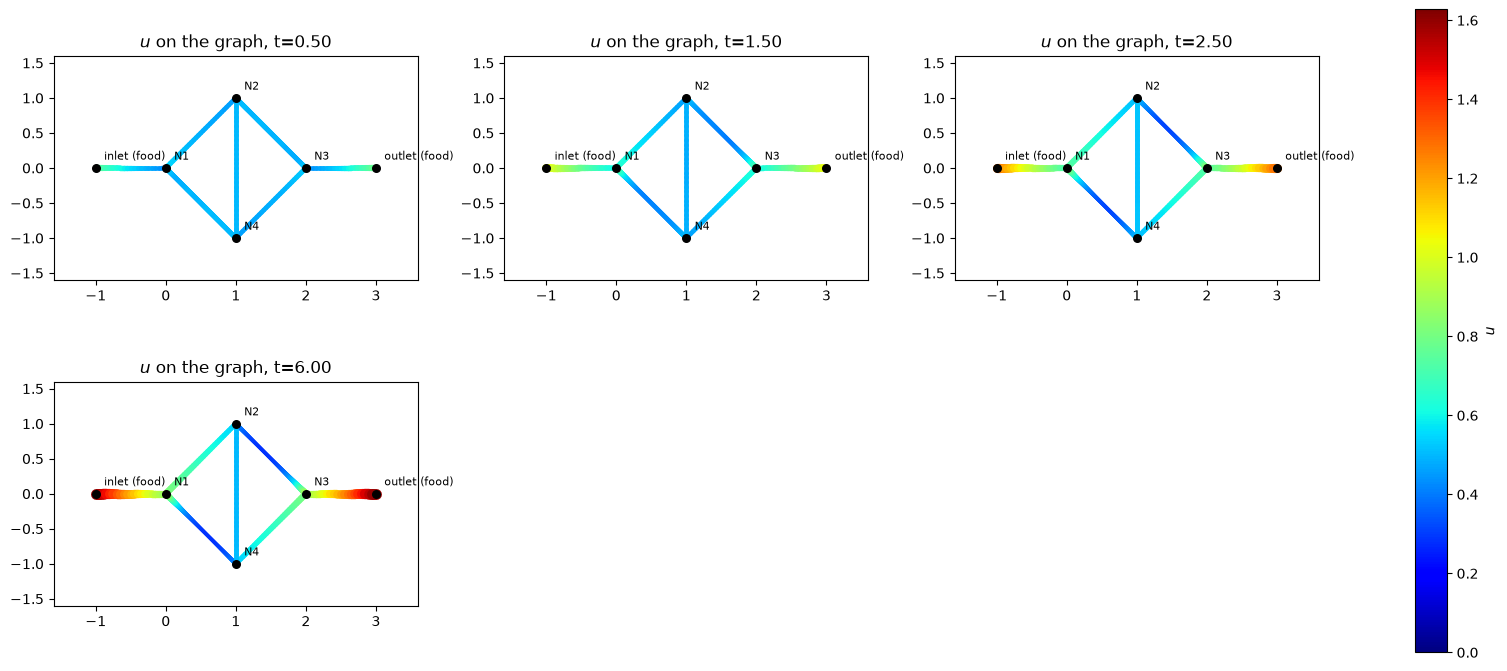

In [6]:
run_A = run(bc_type_A, T=6)
plot_run(run_A, [0.5, 1.5, 2.5, 6])

## Run B: inflow, T = 200

$v_1(0, t) = \frac{2}{1 + u_1(0, t)}$ and $v_7(L_7, t) = -\frac{2}{1 + u_7(L_7, t)}$. Paper snapshots: t = 10, 50, 130, 200.

Without a limiter on $\chi \phi_x$ this run currently goes non-finite before t = 130.

/Users/yakhals/projects/network-chemotaxis/numerical_approximation/src/numerical_approximation/chemotaxis/hyperbolic.py:144: RuntimeWarning: divide by zero encountered in scalar divide
  v_next_0 = 2.0 / (1.0 + u_plus_next_0 + u_minus_next_0)
/Users/yakhals/projects/network-chemotaxis/numerical_approximation/src/numerical_approximation/chemotaxis/hyperbolic.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  v_next_Mp1 = -2.0 / (1.0 + u_plus_next_Mp1 + u_minus_next_Mp1)
/Users/yakhals/projects/network-chemotaxis/numerical_approximation/src/numerical_approximation/chemotaxis/hyperbolic.py:19: RuntimeWarning: overflow encountered in scalar multiply
  c = gamma + known * beta + alpha * known**2
/Users/yakhals/projects/network-chemotaxis/numerical_approximation/src/numerical_approximation/chemotaxis/hyperbolic.py:19: RuntimeWarning: overflow encountered in scalar power
  c = gamma + known * beta + alpha * known**2
/Users/yakhals/projects/network-chemotaxis/numerical_appro

not plotted (non-finite): t = [130.0, 200.0]


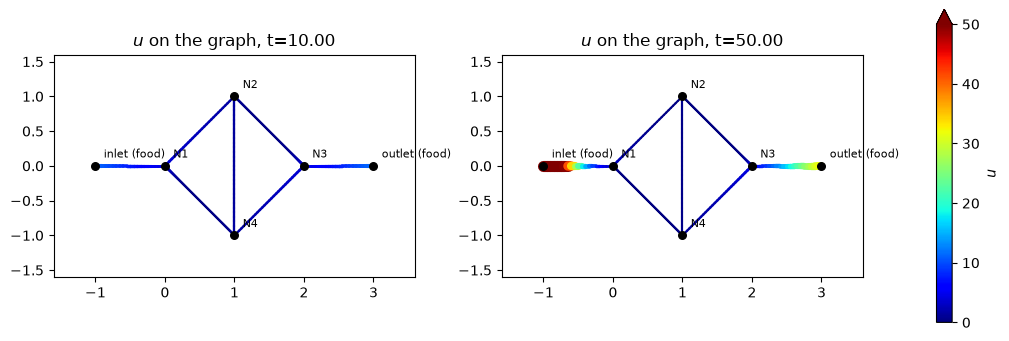

In [7]:
run_B = run(bc_type_B, T=200)
plot_run(run_B, [10, 50, 130, 200], vmax=50)  # the paper's colour scale for this run